In [51]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

In [52]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


In [53]:
if(torch.cuda.is_available()):
    devices = 'cuda'
elif(torch.backends.mps.is_available()):
    devices = 'mps'
else:
    devices = 'cpu'

Form sklearn get dataset for training.

In [54]:
n_samples = 5000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.03) # a little bit of noise to the dots

circles = pd.DataFrame({"X1":X[:,0],
                        "X2":X[:,1],
                        'label':y})
print(circles.head(10))
print(circles.label.value_counts())

         X1        X2  label
0  0.080299  1.024166      0
1 -0.781246  0.610242      0
2 -0.006815 -0.991709      0
3 -0.996326  0.071803      0
4 -0.282820 -0.937594      0
5 -0.742305 -0.334461      1
6  0.920634  0.407064      0
7 -0.655128 -0.467913      1
8  0.705412  0.407824      1
9 -0.902292  0.443170      0
label
0    2500
1    2500
Name: count, dtype: int64


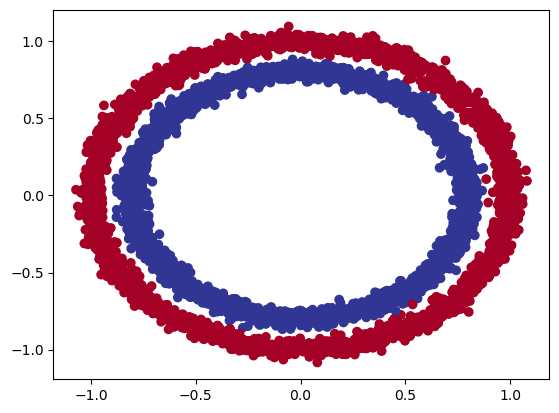

In [55]:
plt.scatter(x=X[:,0],
            y=X[:,1],
            c=y,
            cmap=plt.cm.RdYlBu)

In [56]:
x = torch.from_numpy(X).type(torch.float32).to(devices)
y = torch.from_numpy(y).type(torch.float32).to(devices)
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)

len(x_train), len(x_test), len(y_train), len(y_test)

# X_train, y_train = x_train.to(devices), y_train.to(devices)
# X_test, y_test = x_test.to(devices), y_test.to(devices)



(4000, 1000, 4000, 1000)

In [57]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100 
    return acc

Build model

In [58]:
class Classification_0(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features=2,out_features=4),
            nn.ReLU(),
            nn.Linear(in_features=4,out_features=6),
            nn.ReLU(),
            nn.Linear(in_features=6,out_features=4),
            nn.Linear(in_features=4,out_features=1)
        )
        
    def forward(self,x):
        return self.net(x)

In [59]:
model_0 = Classification_0().to(devices)

loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(model_0.parameters(),lr = 0.05)


In [60]:
epochs = 10000

for epoch in range(epochs):
    y_logits = model_0(x_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits,y_train)
    acc = accuracy_fn(y_true=y_train,y_pred=y_pred)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_0.eval()

    with torch.inference_mode():
        test_logits = model_0(x_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test,
                                y_pred=test_pred)
        
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")






Epoch: 0 | Loss: 0.69307, Accuracy: 50.02% | Test Loss: 0.69310, Test Accuracy: 49.90%
Epoch: 100 | Loss: 0.69245, Accuracy: 53.02% | Test Loss: 0.69239, Test Accuracy: 52.60%
Epoch: 200 | Loss: 0.69232, Accuracy: 52.60% | Test Loss: 0.69224, Test Accuracy: 52.20%
Epoch: 300 | Loss: 0.69221, Accuracy: 52.45% | Test Loss: 0.69210, Test Accuracy: 52.00%
Epoch: 400 | Loss: 0.69209, Accuracy: 52.42% | Test Loss: 0.69196, Test Accuracy: 51.80%
Epoch: 500 | Loss: 0.69196, Accuracy: 52.42% | Test Loss: 0.69180, Test Accuracy: 52.00%
Epoch: 600 | Loss: 0.69181, Accuracy: 52.85% | Test Loss: 0.69164, Test Accuracy: 52.50%
Epoch: 700 | Loss: 0.69165, Accuracy: 53.05% | Test Loss: 0.69145, Test Accuracy: 53.00%
Epoch: 800 | Loss: 0.69147, Accuracy: 53.47% | Test Loss: 0.69125, Test Accuracy: 53.70%
Epoch: 900 | Loss: 0.69127, Accuracy: 55.02% | Test Loss: 0.69101, Test Accuracy: 56.50%
Epoch: 1000 | Loss: 0.69104, Accuracy: 59.40% | Test Loss: 0.69076, Test Accuracy: 60.60%
Epoch: 1100 | Loss: 0.

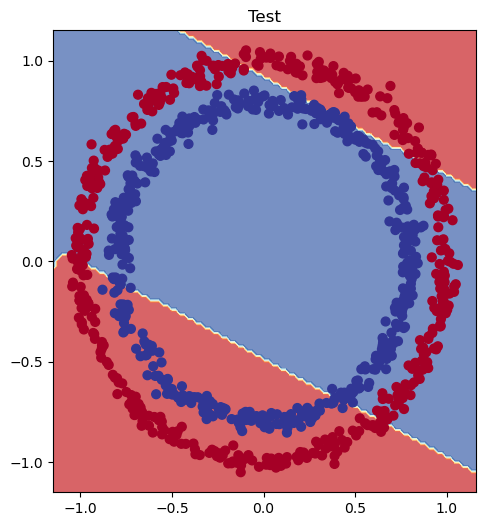

In [61]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Test")
plot_decision_boundary(model_0, x_test, y_test) # model_3 = has non-linearity
plt.show()

Multi-class classification

Create and munge data for training

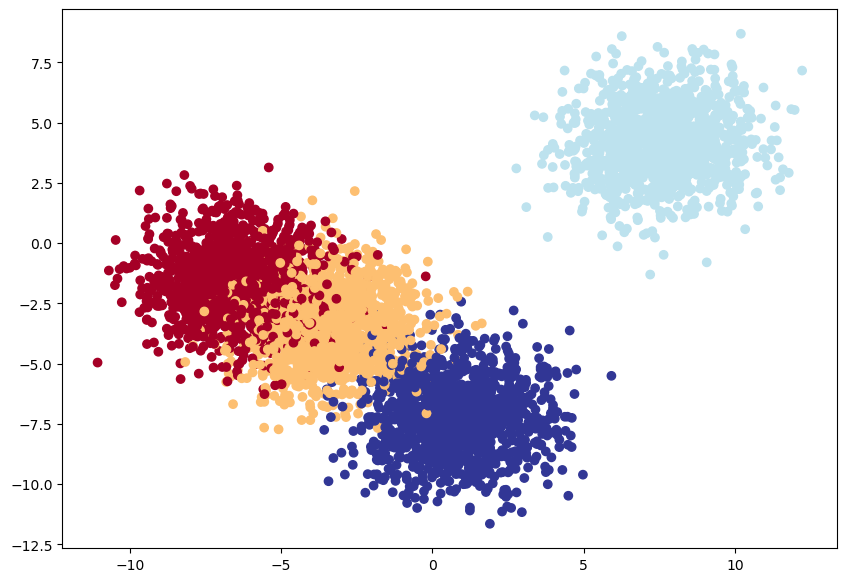

In [62]:
from sklearn.datasets import make_blobs

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2


x_blob , y_blob = make_blobs(n_samples=5000,
                             n_features=NUM_FEATURES,
                             centers=NUM_CLASSES,
                             cluster_std=1.5)


x_blob = torch.from_numpy(x_blob).type(torch.float32).to(devices)
y_blob = torch.from_numpy(y_blob).type(torch.float32).to(devices)

x_blob_train , x_blob_test, y_blob_train, y_blob_test = train_test_split(x_blob,
                                                                         y_blob,test_size=0.2)

figure1 = plt.figure(figsize=(10,7))
plt.scatter(x_blob[:,0].cpu(),x_blob[:,1].cpu(),c=y_blob.cpu(),cmap=plt.cm.RdYlBu)
plt.show()


Create the model

In [63]:
class multilabel(nn.Module):
    def __init__(self,input_features,output_features,hidden_unites):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features,out_features=hidden_unites),
            nn.ReLU(),   # adding relu to make non-linear line
            nn.Linear(in_features=hidden_unites,out_features=hidden_unites),
            nn.ReLU(),
            nn.Linear(in_features=hidden_unites,out_features=output_features)
        )
    
    def forward(self,x):
        return self.layer_stack(x)
    



In [64]:
print(devices)

cuda


Create the model and set loss funciton and optimizer

In [65]:
model_1 = multilabel(input_features=NUM_FEATURES,output_features=NUM_CLASSES,
                     hidden_unites=8).to(devices)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model_1.parameters(),lr=0.01)

In [66]:
epochs = 10000

for epoch in range(epochs):

    model_1.train()

    y_blob_logits = model_1(x_blob_train)

    loss = loss_fn(y_blob_logits,y_blob_train.long())

    y_blob_pred = torch.softmax(y_blob_logits,dim=1).argmax(dim=1)
    acc = accuracy_fn(y_true=y_blob_train.long(),
                      y_pred=y_blob_pred)


    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_1.eval()
    with torch.inference_mode():
        test_logits = model_1(x_blob_test)
        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
        # 2. Calculate test loss and accuracy
        test_loss = loss_fn(test_logits, y_blob_test.long())
        test_acc = accuracy_fn(y_true=y_blob_test.long(),
                                y_pred=test_pred)

    # Print out what's happening
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")



Epoch: 0 | Loss: 1.35366, Acc: 29.60% | Test Loss: 1.29596, Test Acc: 44.80%
Epoch: 10 | Loss: 0.77885, Acc: 75.75% | Test Loss: 0.74402, Test Acc: 81.90%
Epoch: 20 | Loss: 0.46845, Acc: 89.38% | Test Loss: 0.44158, Test Acc: 90.00%
Epoch: 30 | Loss: 0.28778, Acc: 92.27% | Test Loss: 0.26844, Test Acc: 93.10%
Epoch: 40 | Loss: 0.21487, Acc: 92.15% | Test Loss: 0.19876, Test Acc: 92.70%
Epoch: 50 | Loss: 0.19857, Acc: 92.15% | Test Loss: 0.18251, Test Acc: 92.80%
Epoch: 60 | Loss: 0.19054, Acc: 92.53% | Test Loss: 0.17287, Test Acc: 93.30%
Epoch: 70 | Loss: 0.18526, Acc: 92.58% | Test Loss: 0.16780, Test Acc: 93.30%
Epoch: 80 | Loss: 0.18289, Acc: 92.75% | Test Loss: 0.16448, Test Acc: 92.70%
Epoch: 90 | Loss: 0.18100, Acc: 92.73% | Test Loss: 0.16233, Test Acc: 92.80%
Epoch: 100 | Loss: 0.17990, Acc: 92.95% | Test Loss: 0.16119, Test Acc: 92.90%
Epoch: 110 | Loss: 0.17912, Acc: 92.90% | Test Loss: 0.16025, Test Acc: 92.60%
Epoch: 120 | Loss: 0.17851, Acc: 92.97% | Test Loss: 0.15971, T

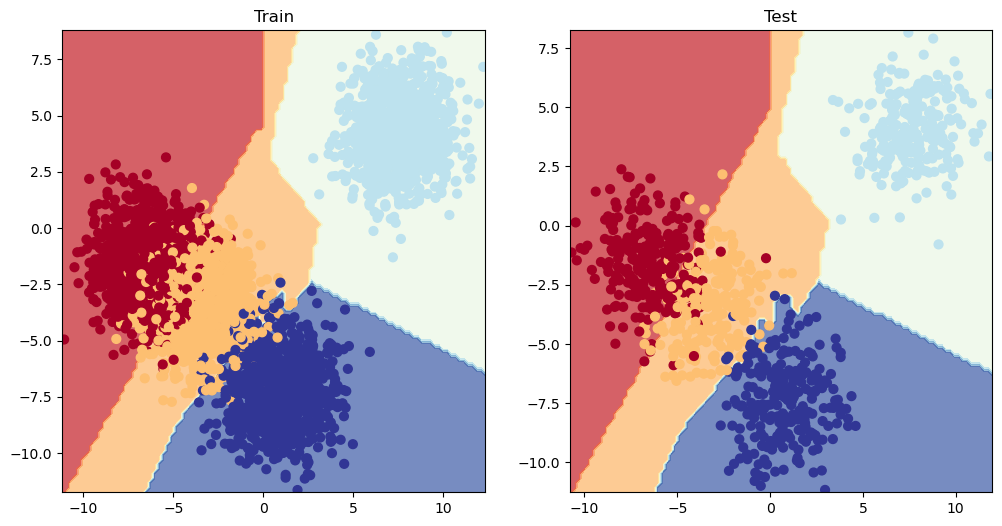

In [67]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, x_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, x_blob_test, y_blob_test)